# Week 04 - REST API, DataFrame and UI Logic

| 항목 | 내용 |
|---|---|
| 이름 | 이성민 |
| 학과 | 소프트웨어융합과 |
| 학년 | 2학년 |
| 학번 | 2151050 |
| 시트 기준 열 | 0327_TASK2 HomeWork |

이 노트북은 과제 요구사항을 학습용으로 재구성한 설명형 산출물이다. 원본 코드를 그대로 복사하지 않고, 같은 개념을 작은 로컬 예제로 다시 구현한다.

## 목표

REST API 응답 구조를 DataFrame으로 바꾸고 필터링 함수와 UI 연결 함수를 설계한다.

모든 코드는 외부 서비스 접속 없이 실행되도록 구성했다. 실제 API나 웹사이트를 사용할 때는 같은 처리 흐름에서 데이터 입력 부분만 교체하면 된다.

## 1. REST 응답을 DataFrame으로 변환

실제 REST API는 JSON을 반환한다. 여기서는 네트워크 요청 대신 API 응답과 같은 리스트/딕셔너리 구조를 만들고 DataFrame으로 변환한다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

response_json = [
    {"id": 1, "userId": 1, "title": "prepare api report", "completed": True},
    {"id": 2, "userId": 1, "title": "clean dataframe", "completed": False},
    {"id": 3, "userId": 2, "title": "design gradio filter", "completed": True},
    {"id": 4, "userId": 3, "title": "write markdown explanation", "completed": False},
    {"id": 5, "userId": 2, "title": "check chart", "completed": True},
]
tasks = pd.DataFrame(response_json)
tasks["status"] = tasks["completed"].map({True: "done", False: "todo"})
tasks

,id,userId,title,completed,status
0,1,1,prepare api report,True,done
1,2,1,clean dataframe,False,todo
2,3,2,design gradio filter,True,done
3,4,3,write markdown explanation,False,todo
4,5,2,check chart,True,done


## 2. 필터링 함수

UI 버튼이나 입력창은 결국 파이썬 함수와 연결된다. 함수가 DataFrame을 받아 조건에 맞는 결과를 반환하면 Gradio 같은 UI도 같은 함수를 호출할 수 있다.

In [2]:
def filter_tasks(user_id: int | None = None, status: str | None = None) -> pd.DataFrame:
    result = tasks.copy()
    if user_id is not None:
        result = result[result["userId"] == user_id]
    if status:
        result = result[result["status"] == status]
    return result.reset_index(drop=True)

def task_summary() -> pd.DataFrame:
    return (
        tasks.groupby(["userId", "status"], as_index=False)
        .agg(count=("id", "count"))
        .sort_values(["userId", "status"])
    )

display(filter_tasks(user_id=2))
display(filter_tasks(status="todo"))
display(task_summary())

,id,userId,title,completed,status
0,3,2,design gradio filter,True,done
1,5,2,check chart,True,done


,id,userId,title,completed,status
0,2,1,clean dataframe,False,todo
1,4,3,write markdown explanation,False,todo


,userId,status,count
0,1,done,1
1,1,todo,1
2,2,done,2
3,3,todo,1


## 3. UI 연결을 함수로 표현

Gradio를 실행하지 않아도 입력값을 받아 결과를 반환하는 핵심 로직은 검증할 수 있다. 이렇게 만들면 UI 의존성과 데이터 처리 의존성을 분리할 수 있다.

In [3]:
def ui_filter(user_id_text: str, status: str) -> str:
    user_id = int(user_id_text) if user_id_text.strip() else None
    status_value = status if status != "all" else None
    result = filter_tasks(user_id=user_id, status=status_value)
    return result.to_string(index=False)

ui_output = ui_filter("2", "done")
print(ui_output)

assert "design gradio filter" in ui_output
assert filter_tasks(status="done")["completed"].all()

 id  userId                title  completed status
  3       2 design gradio filter       True   done
  5       2          check chart       True   done


## 4. 간단한 대시보드 지표

대시보드는 필터, 집계, 시각화의 조합이다. 먼저 집계 테이블이 정확해야 그래프도 신뢰할 수 있다.

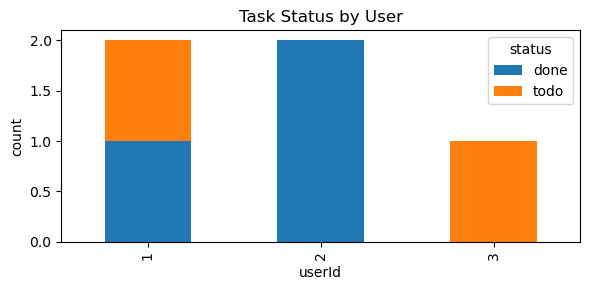

status,done,todo
userId,,
1,1.0,1.0
2,2.0,0.0
3,0.0,1.0


In [4]:
summary = task_summary()
pivot = summary.pivot(index="userId", columns="status", values="count").fillna(0)

ax = pivot.plot(kind="bar", stacked=True, figsize=(6, 3), title="Task Status by User")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

assert int(pivot.sum().sum()) == len(tasks)
pivot